In [53]:
import parcels
import geopandas as gpd 
import sys
import sys
from pathlib import Path
import xarray as xr
from datetime import timedelta
# go to project root (parent of Parcles/)
sys.path.insert(0, str(Path.cwd().parent))
from functions.funcs import *
import functions.plotting
from importlib import reload 
reload(functions.plotting)
import numpy as np

In [70]:
##load some data 
## Loads the Velosity field
fname = r"..\Data\cmems.nc"
field = xr.open_dataset(fname )
##Loads the dFADs 
ds = gpd.read_parquet(r"..\Data\Mapped_SAT_MI_Cleanedspeeds.parquet")

In [ ]:
target_date = pd.to_datetime("2024-03-27", format="%Y-%m-%d") ## picks dFAD locations one day after this date 

ds_active = querry_date(ds, date = target_date) ## All of the active dFADs at this time 
ds_active = ds_active.reset_index()
columns = ["TimeStamp", "x_speed", "y_speed"]
ds_locations = pd.DataFrame()
for label in columns: 
    longlist, ids = Column_to_List(ds_active, label, idlist = True)
     
    ds_locations[label] = longlist
lat, lon  = list_of_latlon(ds_active, droplast= False)
ds_locations["lat"] = lat
ds_locations["lon"] =lon
ds_locations["BuoyName"] = ids
ds_locations.TimeStamp = pd.to_datetime(ds_locations.TimeStamp)
ds_locations["x_speed_prev"] = (ds_locations.groupby("BuoyName")["x_speed"].transform(lambda x: x.rolling(window=2, min_periods=1).mean()))
ds_locations["y_speed_prev"] = (ds_locations.groupby("BuoyName")["y_speed"].transform(lambda x: x.rolling(window=2, min_periods=1).mean()))

##Filter Timestep by certain threshhold to get locations of FADS within closes  
## UPDATE:This might be better to interp these onto the specific time. 
hourlim = 24
time_threshhold  = pd.Timedelta(hours= hourlim)
time_upper  = target_date + time_threshhold ## This is set for dFADs one day after the date 
time_lower = target_date 
ds_locations = ds_locations.query(f"TimeStamp > @time_lower")
ds_locations = ds_locations.query(f"TimeStamp < @time_upper")
print(f"Amount of sampled dFAD within {hourlim} hrs : {len(ds_locations)}")
ds_locations = ds_locations.drop_duplicates(subset=["lat"], keep="first")
ds_locations = ds_locations.drop_duplicates(subset=["lon"], keep="first").reset_index(drop = True)

## New get only the first point of the day for the forcast.

dFADs = ds_locations.sort_values('TimeStamp').groupby("BuoyName").first()
print(f"Number of Unique dFADs/ points avalable: {len(dFADs)}")
dFADs = dFADs.reset_index()

Amount of sampled dFAD within 24 hrs : 117
Number of Unique dFADs/ points avalable: 21


In [ ]:
def persistence_AdvectionRK4(particle, fieldset, time):  # pragma: no cover
    """Advection of particles using fourth-order Runge-Kutta integration.
    with an added persitence model """
    import numpy as np 
    (u1, v1) = fieldset.UV[particle]
    lon1, lat1 = (particle.lon + u1 * 0.5 * particle.dt, particle.lat + v1 * 0.5 * particle.dt)
    (u2, v2) = fieldset.UV[time + 0.5 * particle.dt, particle.depth, lat1, lon1, particle]
    lon2, lat2 = (particle.lon + u2 * 0.5 * particle.dt, particle.lat + v2 * 0.5 * particle.dt)
    (u3, v3) = fieldset.UV[time + 0.5 * particle.dt, particle.depth, lat2, lon2, particle]
    lon3, lat3 = (particle.lon + u3 * particle.dt, particle.lat + v3 * particle.dt)
    (u4, v4) = fieldset.UV[time + particle.dt, particle.depth, lat3, lon3, particle]
    advection_dlon = (u1 + 2 * u2 + 2 * u3 + u4) / 6.0 * particle.dt  # noqa
    advection_dlat = (v1 + 2 * v2 + 2 * v3 + v4) / 6.0 * particle.dt  # noqa

    ## Calculating persistence 
    persistence_dlon = particle.ui*particle.dt
    persistence_dlat = particle.vi*particle.dt

    # Weighting how much persistence to use
    persistence_frac = np.exp(-particle.age/particle.tau)
    if particle.age < 4*particle.tau: 
        #print(particle.dt, particle.ui, persistence_frac)
        persistence_frac = np.exp(-particle.age/particle.tau)
    else: 
        persistence_frac = 0

    # final displacement 
    particle_dlon += persistence_dlon*persistence_frac + advection_dlon*(1- persistence_frac)
    particle_dlat += persistence_dlat*persistence_frac + advection_dlat*(1- persistence_frac)

In [80]:
## Make the model... 
filenames = {"uo": fname, "vo": fname}
#variables  = {"U": "u", "V": "v"}
#dimensions = {"lat": "lat", "lon": "lon"}
variables  = {"U": "uo", "V": "vo"}
dimensions = {"lat": "latitude", "lon": "longitude"}
field_t = field.sel(time = target_date, depth = 15, method = "nearest").drop_vars("time") ## Not 
runtime = pd.Timedelta(days =7)

# fieldsetperm = parcels.FieldSet.from_netcdf(filenames, variables, dimensions)
fieldset  = parcels.FieldSet.from_xarray_dataset(field_t, variables, dimensions, allow_time_extrapolation= True, transpose = True) 
fieldset.add_constant("halo_west", fieldset.U.grid.lon[0])
fieldset.add_constant("halo_east", fieldset.U.grid.lon[-1])
fieldset.add_constant("halo_north", fieldset.U.grid.lat[-1])
fieldset.add_constant("halo_south", fieldset.U.grid.lat[0])
fieldset.add_periodic_halo(zonal = True , meridional= True)

def boundryCondition(particle, fieldset,time):
    if particle.lon < fieldset.halo_west or particle.lon > fieldset.halo_east:
        particle.delete()
    if particle.lat < fieldset.halo_south or particle.lat > fieldset.halo_north:
        particle.delete()
        
def Age(particle, fieldset, time):
    particle.age += particle.dt / 3600
    
dFADs["timedelta"] = (dFADs.TimeStamp - target_date).dt.total_seconds()

Particles = parcels.ScipyParticle.add_variable("age", initial = 0) 
Particles = Particles.add_variable("Buoyindex", to_write = 'once')
Particles = Particles.add_variable("ui", to_write = 'once' )
Particles = Particles.add_variable("vi", to_write = 'once')
Particles = Particles.add_variable("tau",initial = 0.83*24,to_write = 'once')

pset = parcels.ParticleSet.from_list(fieldset, pclass = Particles , lon = dFADs.lon.to_list(), 
                                     lat = dFADs.lat.to_list() , time = dFADs.timedelta, Buoyindex = dFADs.BuoyName.index, ui = dFADs.x_speed_prev/1000/111, vi = dFADs.y_speed_prev/1000/111) 

output_file = pset.ParticleFile(name = "TestParticleFile.zarr", outputdt =timedelta(hours= 1))


In [81]:
pset.execute([persistence_AdvectionRK4, boundryCondition, Age], 
             runtime = timedelta(days = 7), ##this should be 8 days 
             dt = timedelta(minutes =5), 
             output_file = output_file, 
              )

INFO: Output files are stored in TestParticleFile.zarr.


c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\parcels\particleset.py:1127: ParticleSetWarning: Some of the particles have a start time difference that is not a multiple of outputdt. This could cause the first output of some of the particles that start later in the simulation to be at a different time than expected.
  _warn_outputdt_release_desync(outputdt, starttime, self.particledata.data["time_nextloop"])


  0%|          | 300.0/604800.0 [00:00<06:30, 1546.16it/s]

c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\parcels\particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\parcels\particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\parcels\particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|██████████| 604800.0/604800.0 [00:27<00:00, 21730.16it/s]


In [59]:

## Make the model... 
filenames = {"uo": fname, "vo": fname}
#variables  = {"U": "u", "V": "v"}
#dimensions = {"lat": "lat", "lon": "lon"}
variables  = {"U": "uo", "V": "vo"}
dimensions = {"lat": "latitude", "lon": "longitude"}
field_t = field.sel(time = target_date, depth = 15, method = "nearest").drop_vars("time") ## Not 
runtime = pd.Timedelta(days =7)

# fieldsetperm = parcels.FieldSet.from_netcdf(filenames, variables, dimensions)
fieldset  = parcels.FieldSet.from_xarray_dataset(field_t, variables, dimensions, allow_time_extrapolation= True, transpose = True) 
fieldset.add_constant("halo_west", fieldset.U.grid.lon[0])
fieldset.add_constant("halo_east", fieldset.U.grid.lon[-1])
fieldset.add_constant("halo_north", fieldset.U.grid.lat[-1])
fieldset.add_constant("halo_south", fieldset.U.grid.lat[0])
fieldset.add_periodic_halo(zonal = True , meridional= True)

def boundryCondition(particle, fieldset,time):
    if particle.lon < fieldset.halo_west or particle.lon > fieldset.halo_east:
        particle.delete()
    if particle.lat < fieldset.halo_south or particle.lat > fieldset.halo_north:
        particle.delete()
        
def Age(particle, fieldset, time):
    particle.age += particle.dt / 3600
    
dFADs["timedelta"] = (dFADs.TimeStamp - target_date).dt.total_seconds()

Particles = parcels.ScipyParticle.add_variable("age", initial = 0) 
Particles = Particles.add_variable("Buoyindex", to_write = 'once')
Particles = Particles.add_variable("ui", to_write = 'once' )
Particles = Particles.add_variable("vi", to_write = 'once')
Particles = Particles.add_variable("tau",initial = 0.83*24,to_write = 'once')
pset = parcels.ParticleSet.from_list(fieldset, pclass = Particles , lon = dFADs.lon.to_list(), 
                                     lat = dFADs.lat.to_list() , time = dFADs.timedelta, Buoyindex = dFADs.BuoyName.index, ui = dFADs.x_speed/1000/111, vi = dFADs.y_speed/1000/111) 

output_file = pset.ParticleFile(name = "TestParticleFile2.zarr", outputdt =timedelta(hours= 1))
pset.execute([parcels.AdvectionRK4, boundryCondition, Age], 
             runtime = timedelta(days = 7), ##this should be 8 days 
             dt = timedelta(minutes =5), 
             output_file = output_file, )

INFO: Output files are stored in TestParticleFile2.zarr.


c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\parcels\particleset.py:1127: ParticleSetWarning: Some of the particles have a start time difference that is not a multiple of outputdt. This could cause the first output of some of the particles that start later in the simulation to be at a different time than expected.
  _warn_outputdt_release_desync(outputdt, starttime, self.particledata.data["time_nextloop"])


  0%|          | 0/604800.0 [00:00<?, ?it/s]

c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\parcels\particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\parcels\particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
c:\Users\czerfass\AppData\Local\miniforge3\envs\parcels\Lib\site-packages\parcels\particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|██████████| 604800.0/604800.0 [00:33<00:00, 18231.51it/s]


In [82]:
buoy_list = dFADs.BuoyName.tolist()
ds_filtered = ds_active[ds_active["BuoyName"].isin(buoy_list)].reset_index(drop = True)

In [83]:
def Forcast_snippit(ds: gpd.GeoDataFrame, dates, startdate, length)-> gpd.GeoDataFrame: 
    """Grad only the snipbit of dFAD trajectory that lines up with forcast window"""
    ds_s = ds.copy()
    forecast_end = startdate + length
    for i in range(len(ds)): ## Try and grab at the exact start times from dates they should be the same
        timelist = (ds_s.at[i,"TimeStamp"])
        timelist = pd.to_datetime(timelist)
        mask = (timelist >= dates[i]) & (timelist <= forecast_end)
        timelist = timelist[mask]
        coords = np.asarray(ds.at[i,"geometry"].coords)
        filtered_coords = coords[mask]
        ds_s.at[i,"TimeStamp"] = timelist
        if len(filtered_coords) > 1:
             ds_s.at[i,"geometry"] = sp.geometry.LineString(filtered_coords)
        else: 
            ds_s.at[i,"geometry"] = None
    return ds_s

ds_short_t = Forcast_snippit(ds_filtered, dFADs.TimeStamp, target_date, pd.Timedelta(days = 7))

In [84]:
one_dfad  = ds_short_t.query('BuoyName == "M3i+136927"').reset_index(drop = True)

Text(0, 0.5, 'Meridional distance [m]')

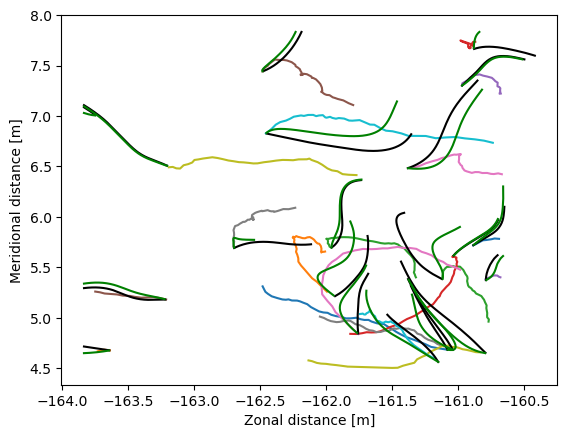

In [85]:
ds_per = xr.open_zarr("TestParticleFile.zarr", decode_timedelta=True)
ds = xr.open_zarr("TestParticleFile2.zarr", decode_timedelta=True)
fig, ax = plt.subplots()
for i in range(len(ds_filtered)):
    ax = functions.plotting.OneTrajectory(ds_short_t, i, ax)

#ax = functions.plotting.OneTrajectory(one_dfad, 0, ax, label = "test", color = "red")
ax.plot(ds.lon.T, ds.lat.T, "-", color = "k")
ax.plot(ds_per.lon.T, ds_per.lat.T, "-", color = "green", label = "persistence")
#plt.scatter(dFADs.lon, dFADs.lat)
ax.set_xlabel("Zonal distance [m]")
ax.set_ylabel("Meridional distance [m]")

In [ ]:
np.printoptions(supress = True, precision= 3 )
print(ds.age.values[1,:])

[  0.8666666   1.866667    2.8666663   3.8666654   4.866667    5.8666687
   6.8666706   7.8666725   8.86667     9.866666   10.866662   11.866658
  12.866654   13.866651   14.866647   15.866643   16.86665    17.866657
  18.866665   19.866673   20.86668    21.866688   22.866695   23.950037
  24.950045   25.950052   26.95006    27.950068   28.950075   29.950083
  30.95009    31.950098   32.950085   33.95007    34.950054   35.95004
  36.950024   37.95001    38.949993   39.949978   40.949963   41.949947
  42.949932   43.949917   44.9499     45.949886   46.94987    47.949856
  48.94984    49.949825   50.94981    51.949795   53.03311    54.033096
  55.03308    56.033066   57.03305    58.033035   59.03302    60.033005
  61.03299    62.032974   63.03296    64.03294    65.032974   66.033005
  67.033035   68.033066   69.0331     70.03313    71.03316    72.03319
  73.03322    74.03325    75.03328    76.03331    77.03334    78.03337
  79.0334     80.03343    81.03346    82.03349    83.03352    84.0

#### Going from model output to CSV Needed
- ideally this is going to be stored in memory and only write when the CSV is full

In [ ]:
output = xr.open_zarr("TestParticleFile.zarr")
display(output)

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_24208\3507518125.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  output = xr.open_zarr("TestParticleFile.zarr")


<xarray.Dataset> Size: 49kB
Dimensions:     (trajectory: 12, obs: 168)
Coordinates:
  * trajectory  (trajectory) int64 96B 10 1 8 0 2 5 7 3 4 6 11 9
  * obs         (obs) int32 672B 0 1 2 3 4 5 6 7 ... 161 162 163 164 165 166 167
Data variables:
    Buoyindex   (trajectory) float32 48B dask.array<chunksize=(12,), meta=np.ndarray>
    age         (trajectory, obs) float32 8kB dask.array<chunksize=(12, 1), meta=np.ndarray>
    lat         (trajectory, obs) float32 8kB dask.array<chunksize=(12, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 8kB dask.array<chunksize=(12, 1), meta=np.ndarray>
    time        (trajectory, obs) timedelta64[ns] 16kB dask.array<chunksize=(12, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 8kB dask.array<chunksize=(12, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4boundryConditionAge
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [ ]:
# print(output.time[2,:].values/1e9)
# print(output.age[2,:].values*3600)

tage = output.age[10,:].values

tage

array([  0.8166666,   1.816667 ,   2.8166664,   3.8166654,   4.8166666,
         5.8166685,   6.8166704,   7.8166723,   8.816669 ,   9.816666 ,
        10.816662 ,  11.816658 ,  12.816654 ,  13.81665  ,  14.816647 ,
        15.816643 ,  16.816648 ,  17.816656 ,  18.816664 ,  19.816671 ,
        20.816679 ,  21.816687 ,  22.816694 ,  23.816702 ,  24.81671  ,
        25.816717 ,  26.816725 ,  27.816732 ,  28.81674  ,  29.816748 ,
        30.816755 ,  31.816763 ,  32.816753 ,  33.81674  ,  34.816723 ,
        35.816708 ,  36.816692 ,  37.816677 ,  38.81666  ,  39.816647 ,
        40.81663  ,  41.816616 ,  42.8166   ,  43.816586 ,  44.81657  ,
        45.816555 ,  46.81654  ,  47.816525 ,  48.81651  ,  49.816494 ,
        50.81648  ,  51.816463 ,  52.81645  ,  53.816433 ,  54.816418 ,
        55.816402 ,  56.816387 ,  57.816372 ,  58.816357 ,  59.81634  ,
        60.816326 ,  61.81631  ,  62.816296 ,  63.81628  ,  64.8163   ,
        65.81633  ,  66.81636  ,  67.81639  ,  68.81642  ,  69.8

In [ ]:
output["date"] = (["trajectory", "obs"],output.time.values + target_date)
output["leadtime"] = (["trajectory", "obs"],(output.time[:,:] - output.time[:,0]).values)
output["leadtimeint"] = (["trajectory", "obs"],output.leadtime[:,:].values.astype("int64")/10e9)

In [ ]:
limelist = ds_short_t.iloc[i,:].TimeStamp -  ds_short_t.iloc[i,:].TimeStamp[0]
limelist.astype("int64")/1e9 ### lead time in seconds


Index([   0.0,   14.4,   28.8,   43.2,   57.6,   72.0,   86.4, 100.86,  115.2,
        129.6,  144.0, 158.46, 172.86, 187.26,  201.6, 216.06,  230.4,  244.8,
        259.2,  273.6,  290.1,  302.4,  316.8,  331.2,  345.6,  360.0, 375.54,
       388.86,  403.2, 417.84,  432.0, 446.46,  460.8,  475.2, 489.78,  504.0,
        518.4, 532.86,  547.2,  561.6,  576.0,  590.4],
      dtype='float64')

In [ ]:
print(len(dFADs))
print(len(ds_short_t))

12
12


In [ ]:
dsout = pd.DataFrame(columns = ["BuoyID","Time", "lat_true", "lon_true", "lat_forcast", "lon_forcast", "leadtime"])
masklarge =~ np.isnan(output.lat[:,:].values)
dFADs_s = dFADs.iloc[output.Buoyindex.values]
# ds_short_ts = ds_short_t[ds_short_t["BuoyName"].isin(dFADs_s.BuoyName.values)]
order = dFADs_s.BuoyName.tolist()
order_map = {name: i for i, name in enumerate(order)}
mask = ds_short_t["BuoyName"].isin(order)
ds_short_ts = (
    ds_short_t[mask]
    .assign(order_index=lambda df: df["BuoyName"].map(order_map))
    .sort_values("order_index")
    .drop(columns="order_index")
    .reset_index(drop=True)
)

for i, index in enumerate(output.Buoyindex.values): 
    id = dFADs.BuoyName[index]
    #row = ds_short_t.query("BuoyName == @id") ## could be faster to sort ds_short first then use index to find dFAD
    row=  ds_short_ts.iloc[i]
    Times= row["TimeStamp"]
    starttime = Times[0]
    dFAD_leadtime = (Times - starttime).total_seconds() ## convets leadtime to seconds
    #print((Times - starttime).total_seconds())
    #print(dFAD_leadtime)
    mask = masklarge[i,:] 
    leadtimes = output.age[i,:].values[mask]*3600 ## converts to seconds also. 
    lats = output.lat[i,:].values[mask]
    lons = output.lon[i,:].values[mask]
    lat_interp = np.interp(dFAD_leadtime[1:], leadtimes,lats)
    lon_interp = np.interp(dFAD_leadtime[1:], leadtimes, lons) 
    lon_true, lat_true= row["geometry"].xy
    Bouylist = [id]*len(lat_true[1:]) 
    #print(len(Bouylist), len (Times), len(lat_true), len(lon_true), len(lon_interp), len(lat_interp), len(leadtimes))
    dstemp= pd.DataFrame({"BuoyID": Bouylist, "Time": Times[1:], "lat_true": lat_true[1:],"lon_true":lon_true[1:], "lat_forcast": lat_interp, "lon_forcast": lon_interp, "leadtime": dFAD_leadtime[1:]/3600 })
    dsout = pd.concat([dsout,dstemp])


In [ ]:
dsout.iloc[100:150]

,BuoyID,Time,lat_true,lon_true,lat_forcast,lon_forcast,leadtime
19,SLX+463259,2024-06-10 13:21:00,7.4284,-163.10567,7.430464,-162.841598,80.016667
20,SLX+463259,2024-06-10 17:21:00,7.4498,-163.13542,7.431638,-162.856246,84.016667
21,SLX+463259,2024-06-10 21:20:00,7.45152,-163.14848,7.432869,-162.870833,88.0
22,SLX+463259,2024-06-11 01:20:00,7.47678,-163.15705,7.434168,-162.885481,92.0
23,SLX+463259,2024-06-11 05:20:00,7.49012,-163.16345,7.435533,-162.900129,96.0
24,SLX+463259,2024-06-11 09:21:00,7.48782,-163.16982,7.436969,-162.914838,100.016667
25,SLX+463259,2024-06-11 13:21:00,7.49565,-163.16925,7.438467,-162.929486,104.016667
26,SLX+463259,2024-06-11 17:21:00,7.49305,-163.17987,7.440031,-162.944134,108.016667
27,SLX+463259,2024-06-11 21:20:00,7.47473,-163.19545,7.441657,-162.958053,112.0
28,SLX+463259,2024-06-12 01:20:00,7.47482,-163.20012,7.443357,-162.971968,116.0
